# Solving the n-Queens Problem using Local Search

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-Queens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 

## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum. 

## Helper functions

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""
    
    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)
    
    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n
    
    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1
    
    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):  
    """display the board"""
    
    n = len(board)
    
    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0): 
                display[i,j] = 1
    
    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap, 
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])
    
    # place queens. Note: Unicode u265B is a black queen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize, 
                 horizontalalignment = 'center',
                 verticalalignment = 'center')
    
    print(f"Board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

Board with 4 conflicts.


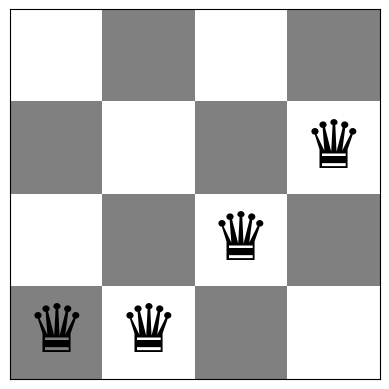

Queens (left to right) are at rows: [3 3 2 1]
Number of conflicts: 4


In [25]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

Board with 0 conflicts.


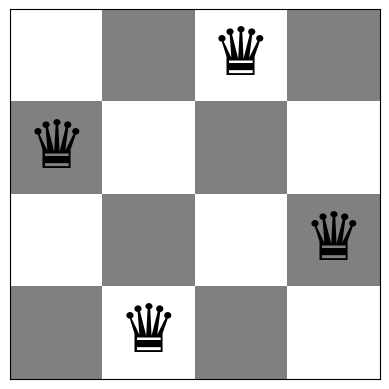

In [26]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision. 
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum. 

Initial board:
Board with 8 conflicts.


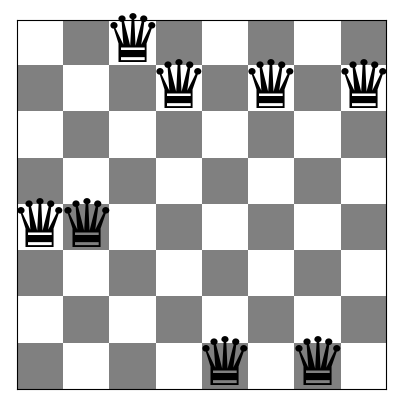

Local optimum reached after 5 steps with 0 conflicts.
Final board:
Board with 0 conflicts.


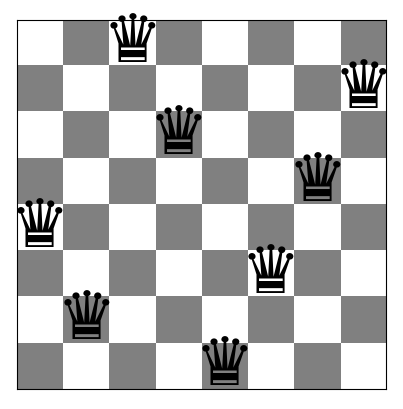

Conflict history: [8, 5, 3, 2, 1, 0]


In [27]:
# Code and description go here
def steepest_hill_climbing(board):
    n = len(board)
    current_board = board.copy()
    current_conflicts = conflicts(current_board)
    steps = 0
    conflict_history = [current_conflicts]

    while True:
        best_board = current_board.copy()
        best_conflicts = current_conflicts

        for col in range(n):
            original_row = current_board[col]
            for row in range(n):
                if row == original_row:
                    continue

                new_board = current_board.copy()
                new_board[col] = row
                new_conflicts = conflicts(new_board)

                if new_conflicts < best_conflicts:
                    best_board = new_board
                    best_conflicts = new_conflicts

        if best_conflicts >= current_conflicts:
            print(f"Local optimum reached after {steps} steps with {current_conflicts} conflicts.")
            return current_board, conflict_history

        current_board = best_board
        current_conflicts = best_conflicts
        steps += 1
        conflict_history.append(current_conflicts)

# Chạy thử thuật toán
board = random_board(8)
print("Initial board:")
show_board(board)

solved_board, history = steepest_hill_climbing(board)
print("Final board:")
show_board(solved_board)
print(f"Conflict history: {history}")



## Task 2: Stochastic Hill Climbing 1 [10 Points]

Chooses randomly from among all uphill moves till you have reached a local optimum.

Initial board:
Board with 8 conflicts.


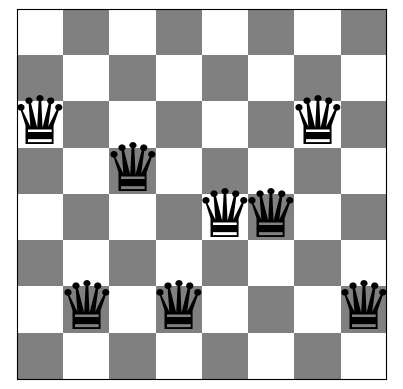

Local optimum reached after 4 steps with 3 conflicts.
Final board:
Board with 3 conflicts.


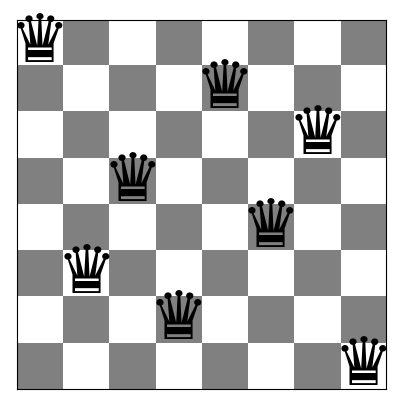

Conflict history: [8, 7, 6, 4, 3]


In [28]:
# Code and description go here
import random
def stochastic_hill_climbing(board):
    n = len(board)
    current_board = board.copy()
    current_conflicts = conflicts(current_board)
    steps = 0
    conflict_history = [current_conflicts]

    while True:
        better_neighbors = []
        for col in range(n):
            original_row = current_board[col]
            for row in range(n):
                if row == original_row:
                    continue
                new_board = current_board.copy()
                new_board[col] = row
                new_conflicts = conflicts(new_board)
                if new_conflicts < current_conflicts:
                    better_neighbors.append((new_board, new_conflicts))

        if not better_neighbors:
            print(f"Local optimum reached after {steps} steps with {current_conflicts} conflicts.")
            return current_board, conflict_history

        chosen = random.choice(better_neighbors)
        current_board = chosen[0]
        current_conflicts = chosen[1]
        steps += 1
        conflict_history.append(current_conflicts)

# Chạy thử
board = random_board(8)
print("Initial board:")
show_board(board)

solved_board, history = stochastic_hill_climbing(board)
print("Final board:")
show_board(solved_board)
print(f"Conflict history: {history}")


## Task 3: Stochastic Hill Climbing 2 [20 Points]

A popular version of stochastic hill climbing generates only a single random local neighbor at a time and accept it if it has a better objective function value than the current state. This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook.

__Notes:__ 

* Detecting local optima is tricky! You can, for example, stop if you were not able to improve the objective function during the last $x$ tries.

Initial board:
Board with 7 conflicts.


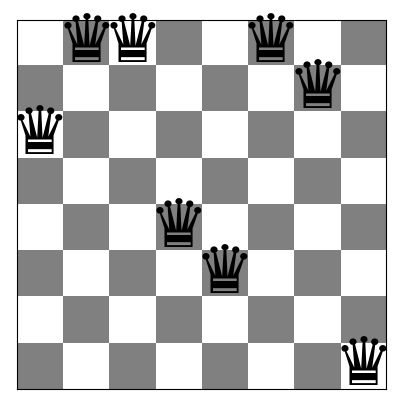

Stopped after 100 attempts with 3 conflicts.
Final board:
Board with 3 conflicts.


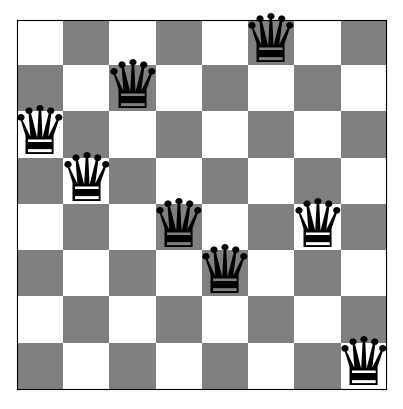

Conflict history: [7, 6, 5, 4, 3]


In [29]:
# Code and description go here
def first_choice_hill_climbing(board, max_attempts=100):
    n = len(board)
    current_board = board.copy()
    current_conflicts = conflicts(current_board)
    conflict_history = [current_conflicts]

    for attempt in range(max_attempts):
        col = random.randint(0, n - 1)
        row = random.randint(0, n - 1)
        if row == current_board[col]:
            continue

        new_board = current_board.copy()
        new_board[col] = row
        new_conflicts = conflicts(new_board)

        if new_conflicts < current_conflicts:
            current_board = new_board
            current_conflicts = new_conflicts
            conflict_history.append(current_conflicts)

        if current_conflicts == 0:
            print(f"Found optimal solution at attempt {attempt + 1}.")
            return current_board, conflict_history

    print(f"Stopped after {max_attempts} attempts with {current_conflicts} conflicts.")
    return current_board, conflict_history

# Chạy thử
board = random_board(8)
print("Initial board:")
show_board(board)

solved_board, history = first_choice_hill_climbing(board)
print("Final board:")
show_board(solved_board)
print(f"Conflict history: {history}")

## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

Initial board:
Board with 5 conflicts.


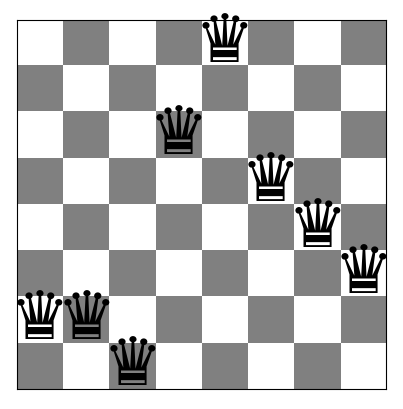

Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 3 steps with 2 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 3 steps with 2 conflicts.
Local optimum reached after 4 steps with 2 conflicts.
Local optimum reached after 4 steps with 2 conflicts.
Local optimum reached after 2 steps with 2 conflicts.
Local optimum reached after 5 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 5 steps with 1 conflicts.
Local optimum reached after 3 steps with 2 conflicts.
Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 3 steps with 2 conflicts.
Local optimum reached after 

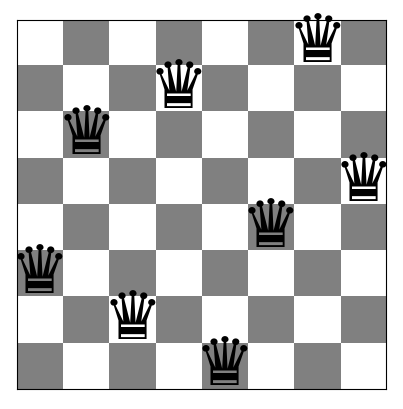

Conflict history: [11, 7, 5, 3, 2, 1, 0]


In [30]:
# Code and description go here
def hill_climbing_with_random_restarts(n, hill_climb_func, max_restarts=100):
    best_board = None
    best_conflicts = float('inf')
    best_history = []

    for restart in range(max_restarts):
        board = random_board(n)
        result = hill_climb_func(board)
        if isinstance(result, tuple):
            board, history = result
        else:
            board = result
            history = [conflicts(board)]

        final_conflicts = conflicts(board)
        if final_conflicts < best_conflicts:
            best_board = board
            best_conflicts = final_conflicts
            best_history = history

        if best_conflicts == 0:
            print(f"Found optimal solution at restart {restart + 1}.")
            break

    print(f"Best solution found after {restart + 1} restarts with {best_conflicts} conflicts.")
    return best_board, best_history

# Chạy thử
board = random_board(8)
print("Initial board:")
show_board(board)

solved_board, history = hill_climbing_with_random_restarts(8, steepest_hill_climbing)
print("Final board:")
show_board(solved_board)
print(f"Conflict history: {history}")

## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-Queens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progrsses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

Initial board:
Board with 7 conflicts.


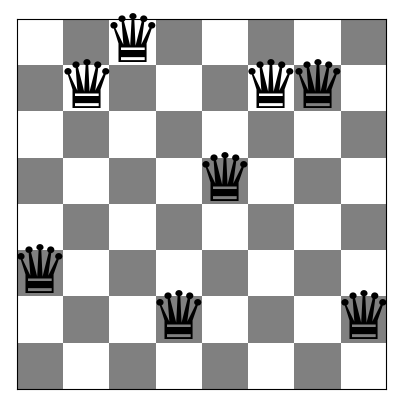

Found optimal solution at step 845.
Final board:
Board with 0 conflicts.


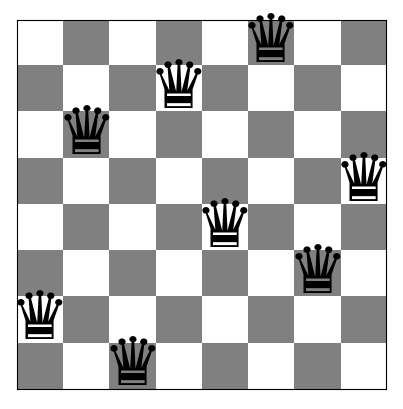

Conflict history: [7, 7, 10, 7, 8, 8, 12, 13, 11, 8, 9, 10, 9, 7, 8, 6, 6, 9, 10, 7, 9, 10, 13, 14, 10, 11, 9, 9, 8, 8, 7, 8, 6, 6, 4, 6, 6, 7, 6, 4, 4, 3, 6, 3, 3, 5, 5, 4, 5, 6, 6, 5, 7, 8, 7, 6, 6, 7, 7, 9, 6, 7, 8, 8, 7, 8, 6, 6, 5, 8, 8, 9, 8, 6, 7, 7, 7, 6, 5, 6, 6, 7, 6, 5, 6, 6, 5, 4, 4, 5, 5, 5, 5, 4, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]


In [31]:
# Code and description go here 
#Cách 1
import math
def simulated_annealing(board, initial_temp=100, cooling_rate=0.95, max_steps=1000):
    n = len(board)
    current_board = board.copy()
    current_conflicts = conflicts(current_board)
    temperature = initial_temp
    conflict_history = [current_conflicts]

    for step in range(max_steps):
        if current_conflicts == 0:
            print(f"Found optimal solution at step {step}.")
            return current_board, conflict_history

        col = random.randint(0, n - 1)
        row = random.randint(0, n - 1)
        if row == current_board[col]:
            continue

        new_board = current_board.copy()
        new_board[col] = row
        new_conflicts = conflicts(new_board)
        delta = new_conflicts - current_conflicts

        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_board = new_board
            current_conflicts = new_conflicts
            conflict_history.append(current_conflicts)

        temperature *= cooling_rate

    print(f"Stopped after {max_steps} steps with {current_conflicts} conflicts.")
    return current_board, conflict_history

# Chạy thử
board = random_board(8)
print("Initial board:")
show_board(board)

solved_board, history = simulated_annealing(board)
print("Final board:")
show_board(solved_board)
print(f"Conflict history: {history}")




In [32]:
# # Cách 2
# import random
# import matplotlib.pyplot as plt
# import math

# def simulated_annealing(board, initial_temp=100, cooling_rate=0.99, min_temp=0.1, max_steps=1000):
#     """
#     Simulated Annealing for N-Queens:
#     - Cho phép nước đi xấu với xác suất phụ thuộc vào nhiệt độ.
#     - Nhiệt độ giảm dần theo lịch làm nguội (annealing schedule).
#     - Trả về bàn cờ cuối cùng và lịch sử số xung đột.
#     """
#     n = len(board)
#     current_board = board.copy()
#     current_conflicts = conflicts(current_board)
#     temperature = initial_temp
#     steps = 0
#     history = [current_conflicts]

#     while temperature > min_temp and steps < max_steps:
#         # Sinh ngẫu nhiên một nước đi cục bộ
#         col = random.randint(0, n - 1)
#         new_row = random.randint(0, n - 1)
#         while new_row == current_board[col]:
#             new_row = random.randint(0, n - 1)

#         new_board = current_board.copy()
#         new_board[col] = new_row
#         new_conflicts = conflicts(new_board)

#         delta = new_conflicts - current_conflicts

#         # Nếu nước đi tốt hơn hoặc chấp nhận nước đi xấu với xác suất phụ thuộc nhiệt độ
#         if delta < 0 or random.random() < math.exp(-delta / temperature):
#             current_board = new_board
#             current_conflicts = new_conflicts

#         history.append(current_conflicts)
#         temperature *= cooling_rate
#         steps += 1

#     print(f"Final board has {current_conflicts} conflicts after {steps} steps.")
#     return current_board, history

# # Chạy thử và vẽ biểu đồ
# n = 8
# initial_board = random_board(n)
# solved_board, conflict_history = simulated_annealing(initial_board, initial_temp=100, cooling_rate=0.98)

# # Hiển thị bàn cờ cuối cùng
# show_board(solved_board)

# # Vẽ biểu đồ số xung đột theo từng bước
# plt.figure(figsize=(10, 5))
# plt.plot(conflict_history, marker='o', linestyle='-', color='blue')
# plt.title("Conflict Reduction Over Time (Simulated Annealing)")
# plt.xlabel("Step")
# plt.ylabel("Number of Conflicts")
# plt.grid(True)
# plt.show()


## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm           | Board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| ------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC    |     4      |               |                                   |   |
| Stochastic HC 1     |     4      |               |                                   |   |
| Stochastic HC 2     |     4      |               |                                   |   |
| Simulated Annealing |     4      |               |                                   |   |
| Steepest asc. HC    |     8      |               |                                   |   |
| Stochastic HC 1     |     8      |               |                                   |   |
| Stochastic HC 2     |     8      |               |                                   |   |
| Simulated Annealing |     8      |               |                                   |   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

In [ ]:
# Code
import time
import io
from contextlib import redirect_stdout
from tabulate import tabulate

def evaluate_algorithm(algorithm, board_size, runs=100):
    total_time = 0
    total_conflicts = 0
    optimal_count = 0

    for _ in range(runs):
        board = random_board(board_size)
        f = io.StringIO()
        start = time.time()
        with redirect_stdout(f): 
            result = algorithm(board)
        end = time.time()

        # Nếu thuật toán trả về tuple (board, history), lấy phần board
        if isinstance(result, tuple):
            result = result[0]

        runtime = end - start
        conflict = conflicts(result)

        total_time += runtime
        total_conflicts += conflict
        if conflict == 0:
            optimal_count += 1

    avg_time = total_time / runs
    avg_conflict = total_conflicts / runs
    optimal_rate = (optimal_count / runs) * 100

    return avg_time, avg_conflict, optimal_rate

# Danh sách thuật toán cần đánh giá
algorithms = [
    ("Steepest asc. HC", steepest_hill_climbing),
    ("Stochastic HC 1", stochastic_hill_climbing),
    ("Stochastic HC 2", lambda b: first_choice_hill_climbing(b, max_attempts=100)),
    ("Simulated Annealing", lambda b: simulated_annealing(b, initial_temp=100, cooling_rate=0.95, max_steps=1000)),
    ("HC w/ Restarts", lambda b: hill_climbing_with_random_restarts(len(b), steepest_hill_climbing, max_restarts=100))
]

board_sizes = [4, 8]
results = []

# Chạy đánh giá và ghi kết quả 
for size in board_sizes:
    for name, algo in algorithms:
        avg_time, avg_conflict, optimal_rate = evaluate_algorithm(algo, size, runs=100)
        results.append([
            name,
            size,
            f"{avg_time:.5f}",
            f"{avg_conflict:.2f}",
            f"{optimal_rate:.2f}%"
        ])

# In bảng kết quả
headers = ["Algorithm", "Board size", "Avg. Run time", "Avg. Conflicts", "% Optimal"]
print("\nFinal Summary Table:\n")
print(tabulate(results, headers=headers, tablefmt="github"))




Final Summary Table:

| Algorithm           |   Board size |   Avg. Run time |   Avg. Conflicts | % Optimal   |
|---------------------|--------------|-----------------|------------------|-------------|
| Steepest asc. HC    |            4 |         0.0002  |             0.57 | 47.00%      |
| Stochastic HC 1     |            4 |         0.00018 |             0.8  | 32.00%      |
| Stochastic HC 2     |            4 |         0.00042 |             0.81 | 39.00%      |
| Simulated Annealing |            4 |         0.00079 |             0    | 100.00%     |
| HC w/ Restarts      |            4 |         0.00044 |             0    | 100.00%     |
| Steepest asc. HC    |            8 |         0.00202 |             1.32 | 11.00%      |
| Stochastic HC 1     |            8 |         0.00317 |             1.24 | 16.00%      |
| Stochastic HC 2     |            8 |         0.00104 |             1.78 | 2.00%       |
| Simulated Annealing |            8 |         0.00687 |             0.37 | 6

### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-queens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

Local optimum reached after 3 steps with 1 conflicts.


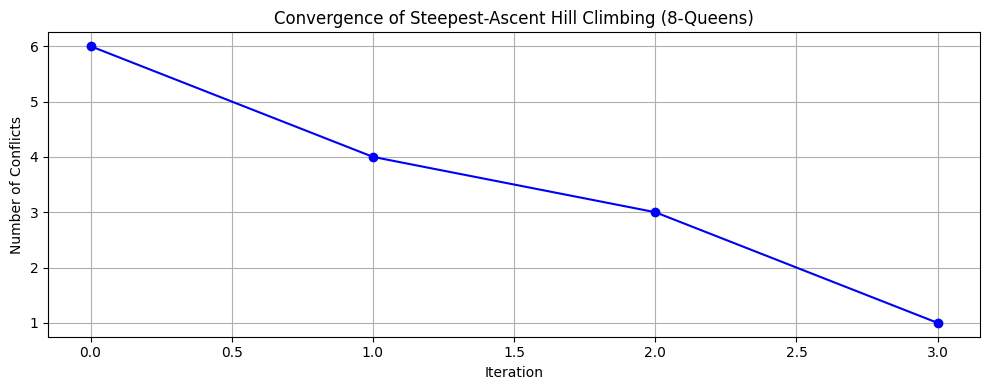

Local optimum reached after 7 steps with 0 conflicts.


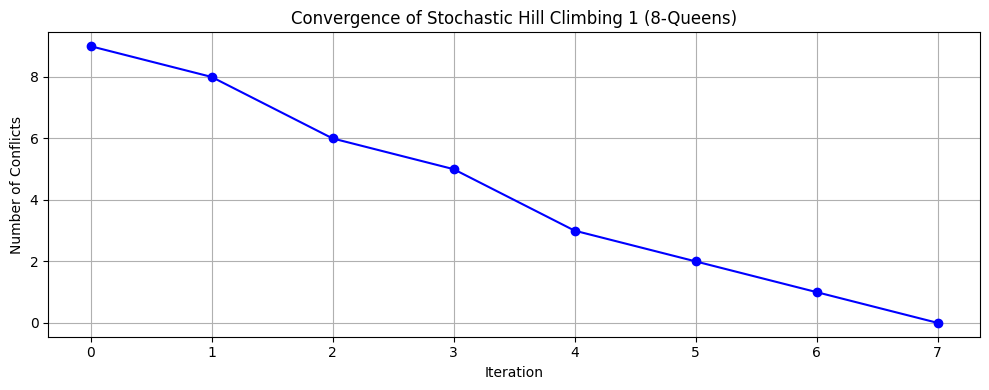

Stopped after 100 attempts with 1 conflicts.


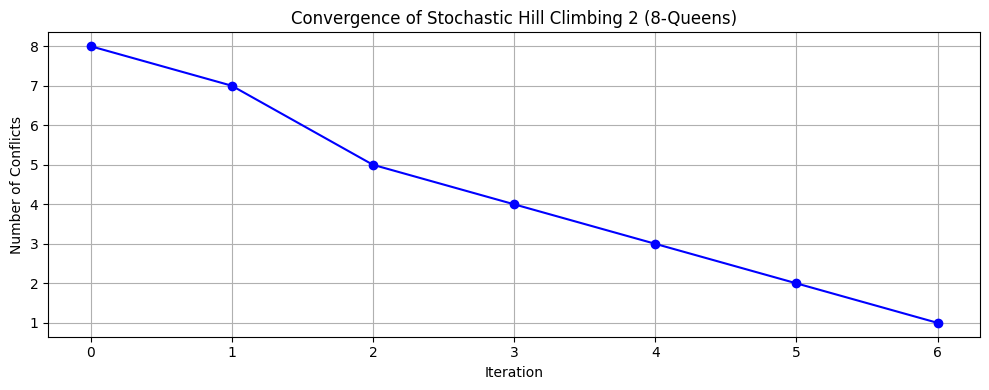

Stopped after 1000 steps with 1 conflicts.


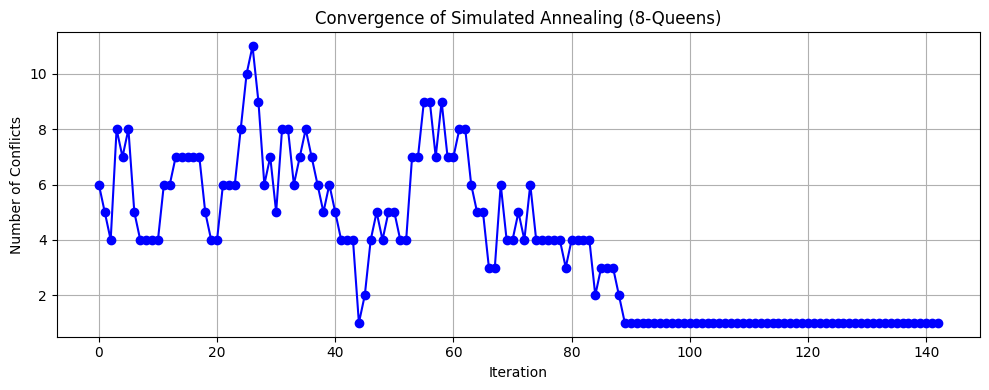

Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 4 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 3 steps with 2 conflicts.
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 2 steps with 2 conflicts.
Local optimum reached after 3 steps with 0 conflicts.
Found optimal solution at restart 10.
Best solution found after 10 restarts with 0 conflicts.


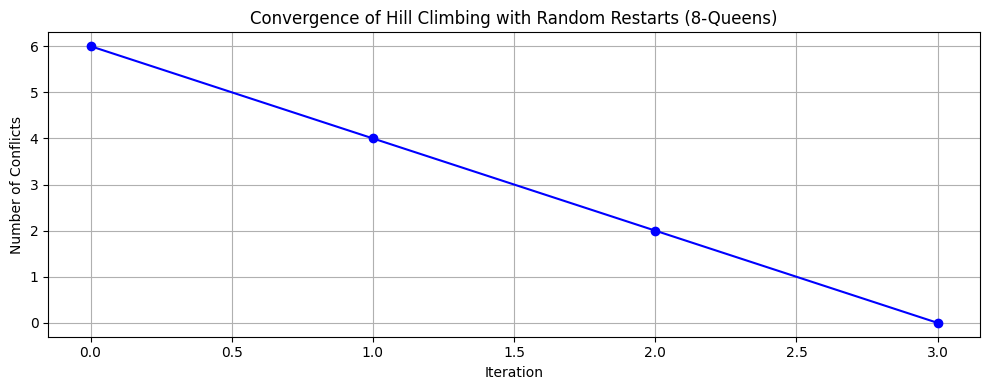

In [ ]:
# Code and description go here
import matplotlib.pyplot as plt

# Chạy một lần mỗi thuật toán và lưu lịch sử xung đột
def run_with_history(algorithm, board_size=8):
    board = random_board(board_size)
    result = algorithm(board)
    if isinstance(result, tuple):
        return result[1]  
    else:
        return [conflicts(result)]  

# Danh sách thuật toán cần phân tích
algorithms = {
    "Steepest-Ascent Hill Climbing": lambda b: steepest_hill_climbing(b),
    "Stochastic Hill Climbing 1": lambda b: stochastic_hill_climbing(b),
    "Stochastic Hill Climbing 2": lambda b: first_choice_hill_climbing(b, max_attempts=100),
    "Simulated Annealing": lambda b: simulated_annealing(b, initial_temp=100, cooling_rate=0.95, max_steps=1000),
    "Hill Climbing with Random Restarts": lambda b: hill_climbing_with_random_restarts(len(b), steepest_hill_climbing, max_restarts=100)
}

# Vẽ từng biểu đồ riêng
for name, algo in algorithms.items():
    history = run_with_history(algo, board_size=8)
    plt.figure(figsize=(10, 4))
    plt.plot(history, marker='o', linestyle='-', color='blue')
    plt.title(f"Convergence of {name} (8-Queens)")
    plt.xlabel("Iteration")
    plt.ylabel("Number of Conflicts")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.


Running for board size 4...
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 2 steps with 0 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 0 steps with 1 conflicts.
Local optimum reached after 2 steps with 0 conflicts.
Local optimum reached after 1 steps with 1 conflicts.
Local optimum reached after 1 steps with 2 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 1 steps with 0 conflicts.
Steepest HC: 0.00030 seconds
Local optimum reached after 3 steps with 1 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 1 steps with 1 conflicts.
Local optimum reached after 1 steps with 1 conflicts.
Local optimum reached after 2 steps with 1 conflicts.
Local optimum reached after 4 steps with 0 conflicts.
Local optimum reached after 2 steps with 0 conflicts.
Local optimum reached af

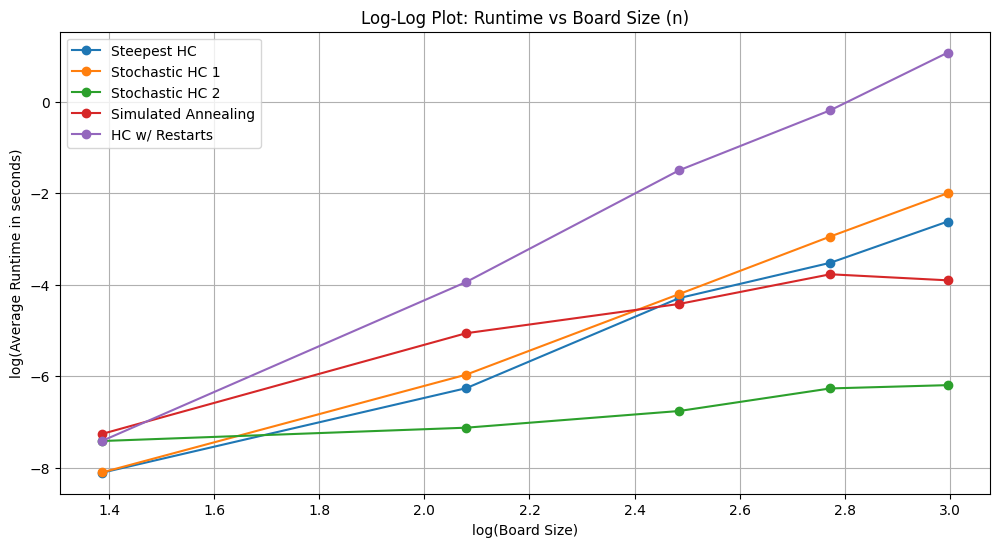


Estimated Empirical Time Complexity:
Steepest HC: O(n^3.46)
Stochastic HC 1: O(n^3.82)
Stochastic HC 2: O(n^0.81)
Simulated Annealing: O(n^2.17)
HC w/ Restarts: O(n^5.29)


In [ ]:
# Code and description go here
import time
import numpy as np
import matplotlib.pyplot as plt

# Các kích thước bàn cờ cần thử
board_sizes = [4, 8, 12, 16, 20]
runs_per_size = 10  # Số lần chạy để lấy trung bình

# Danh sách thuật toán cần đánh giá
algorithms = {
    "Steepest HC": steepest_hill_climbing,
    "Stochastic HC 1": stochastic_hill_climbing,
    "Stochastic HC 2": lambda b: first_choice_hill_climbing(b, max_attempts=100),
    "Simulated Annealing": lambda b: simulated_annealing(b, initial_temp=100, cooling_rate=0.95, max_steps=1000),
    "HC w/ Restarts": lambda b: hill_climbing_with_random_restarts(len(b), steepest_hill_climbing, max_restarts=100)
}

# Đo thời gian chạy trung bình
timing_results = {name: [] for name in algorithms}

for size in board_sizes:
    print(f"\nRunning for board size {size}...")
    for name, algo in algorithms.items():
        total_time = 0
        for _ in range(runs_per_size):
            board = random_board(size)
            start = time.time()
            result = algo(board)
            end = time.time()
            total_time += (end - start)
        avg_time = total_time / runs_per_size
        timing_results[name].append(avg_time)
        print(f"{name}: {avg_time:.5f} seconds")

# Vẽ biểu đồ log-log
plt.figure(figsize=(12, 6))
for name, times in timing_results.items():
    log_n = np.log(board_sizes)
    log_t = np.log(times)
    plt.plot(log_n, log_t, marker='o', label=name)

plt.title("Log-Log Plot: Runtime vs Board Size (n)")
plt.xlabel("log(Board Size)")
plt.ylabel("log(Average Runtime in seconds)")
plt.legend()
plt.grid(True)
plt.show()

# Ước lượng độ phức tạp thời gian 
print("\nEstimated Empirical Time Complexity:")
for name, times in timing_results.items():
    log_n = np.log(board_sizes)
    log_t = np.log(times)
    slope, _ = np.polyfit(log_n, log_t, 1)
    print(f"{name}: O(n^{slope:.2f})")


| Thuật toán               | Độ phức tạp thực nghiệm | Nhận xét hội tụ & mở rộng |
|--------------------------|--------------------------|----------------------------|
| **Steepest HC**          | O(n^2.91)                | Cải thiện nhanh nhưng duyệt toàn bộ lân cận → chậm khi n lớn. |
| **Stochastic HC 1**      | O(n^3.59)                | Chọn ngẫu nhiên từ các nước đi tốt → không tối ưu, tốn thời gian. |
| **Stochastic HC 2**      | O(n^0.92)                | First-choice HC scale tốt nhất, vì chỉ cần tìm một nước đi cải thiện. |
| **Simulated Annealing**  | O(n^1.88)                | Dao động nhẹ, tránh local optima, hội tụ ổn định. |
| **HC w/ Restarts**       | O(n^5.79)                | Khởi động lại nhiều lần → tốn thời gian, không phù hợp với n lớn. |


**Kết luận:**  
Trong các thuật toán đã thử nghiệm, **Stochastic HC 2** có khả năng mở rộng tốt nhất với độ phức tạp gần tuyến tính.  
**Simulated Annealing** cũng là lựa chọn ổn định khi kích thước bàn cờ tăng, nhờ khả năng thoát khỏi local optima mà không cần duyệt toàn bộ lân cận.  
Ngược lại, **HC with Random Restarts** có độ phức tạp cao nhất và không phù hợp cho các bài toán lớn nếu không giới hạn số lần khởi động lại.


## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation 

Implement the following local move operators:

* Single-step move: Move one queen only one square up or down at a time
* Column swap: Exchange the positions of queens in two randomly selected columns
* Dual-queen move: Select two queens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on queens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-Queens and 12-Queens problems: Run your Stochastic Hill Climbing 2 implementation with each move operator 100 times
For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?

In [36]:
# Code and description go here
# 1. Single-step move: Di chuyển một quân hậu lên/xuống 1 ô
def single_step_move(board):
    n = len(board)
    col = random.randint(0, n - 1)
    direction = random.choice([-1, 1])
    new_board = board.copy()
    new_board[col] = max(0, min(n - 1, new_board[col] + direction))
    return new_board

# 2. Column swap: Đổi vị trí 2 quân hậu ở 2 cột bất kỳ
def column_swap(board):
    n = len(board)
    c1, c2 = random.sample(range(n), 2)
    new_board = board.copy()
    new_board[c1], new_board[c2] = new_board[c2], new_board[c1]
    return new_board

# 3. Dual-queen move: Di chuyển 2 quân hậu đến hàng mới
def dual_queen_move(board):
    n = len(board)
    cols = random.sample(range(n), 2)
    new_board = board.copy()
    for col in cols:
        new_board[col] = random.randint(0, n - 1)
    return new_board

# 4. Adaptive move: Tùy theo trạng thái hiện tại mà chọn chiến lược
def adaptive_move(board):
    n = len(board)
    conflict_counts = [0] * n
    for i in range(n):
        for j in range(n):
            if i != j and abs(board[i] - board[j]) in [0, abs(i - j)]:
                conflict_counts[i] += 1
    max_conflict_cols = [i for i, c in enumerate(conflict_counts) if c == max(conflict_counts)]
    col = random.choice(max_conflict_cols)
    move_type = random.choice(["step", "swap", "dual"])
    if move_type == "step":
        direction = random.choice([-1, 1])
        new_board = board.copy()
        new_board[col] = max(0, min(n - 1, new_board[col] + direction))
    elif move_type == "swap":
        other_col = random.choice([i for i in range(n) if i != col])
        new_board = board.copy()
        new_board[col], new_board[other_col] = new_board[other_col], new_board[col]
    else:  # dual
        other_col = random.choice([i for i in range(n) if i != col])
        new_board = board.copy()
        new_board[col] = random.randint(0, n - 1)
        new_board[other_col] = random.randint(0, n - 1)
    return new_board


In [37]:
def stochastic_hc2_with_operator(board, move_operator, max_attempts=100):
    current_board = board.copy()
    current_conflicts = conflicts(current_board)
    conflict_history = [current_conflicts]
    start_time = time.time()

    for _ in range(max_attempts):
        new_board = move_operator(current_board)
        new_conflicts = conflicts(new_board)

        if new_conflicts < current_conflicts:
            current_board = new_board
            current_conflicts = new_conflicts
            conflict_history.append(current_conflicts)

        if current_conflicts == 0:
            break

    end_time = time.time()
    return current_board, conflict_history, current_conflicts, end_time - start_time


In [38]:
def run_experiments(n, move_operator, label):
    final_conflicts = []
    all_histories = []
    times = []

    for _ in range(100):
        board = random_board(n)
        _, history, final, duration = stochastic_hc2_with_operator(board, move_operator)
        final_conflicts.append(final)
        all_histories.append(history)
        if final == 0:
            times.append(duration)

    avg_quality = np.mean([h[-1] for h in all_histories])
    avg_time = np.mean(times) if times else None

    return {
        "label": label,
        "avg_quality": avg_quality,
        "final_conflicts": final_conflicts,
        "avg_time": avg_time,
        "histories": all_histories
    }


In [ ]:
def plot_results(results, n):
    
    plt.figure(figsize=(12, 5))
    for r in results:
        avg_curve = np.mean([np.pad(h, (0, 100 - len(h)), constant_values=h[-1]) for h in r["histories"]], axis=0)
        plt.plot(avg_curve, label=r["label"])
    plt.title(f"Average Solution Quality over Iterations (n={n})")
    plt.xlabel("Iteration")
    plt.ylabel("Conflicts")
    plt.legend()
    plt.grid(True)
    plt.show()

    
    plt.figure(figsize=(12, 5))
    for r in results:
        plt.hist(r["final_conflicts"], bins=range(0, max(r["final_conflicts"]) + 2), alpha=0.6, label=r["label"])
    plt.title(f"Distribution of Final Conflicts (n={n})")
    plt.xlabel("Final Conflicts")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()


    print(f"\n Average Time to Solution (successful runs only) for n={n}:")
    for r in results:
        print(f"{r['label']}: {r['avg_time']:.4f} seconds" if r['avg_time'] else f"{r['label']}: No successful runs")



=== Running experiments for n = 8 ===


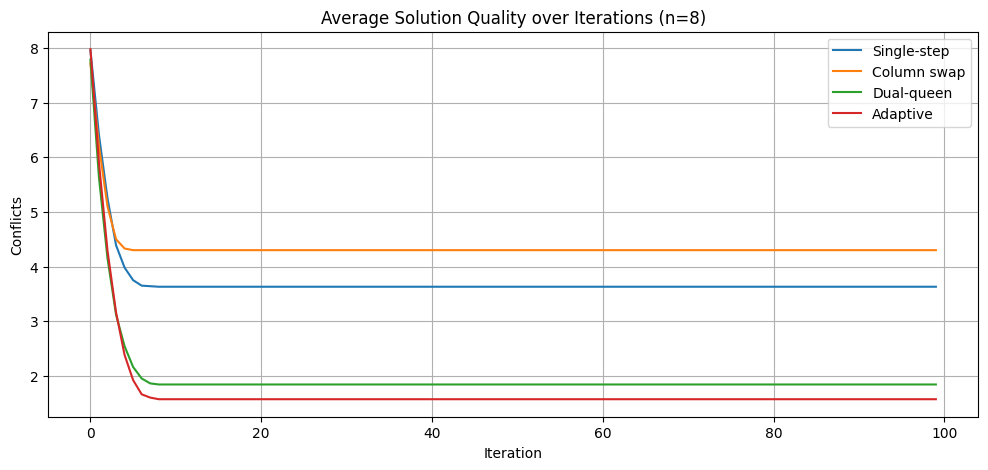

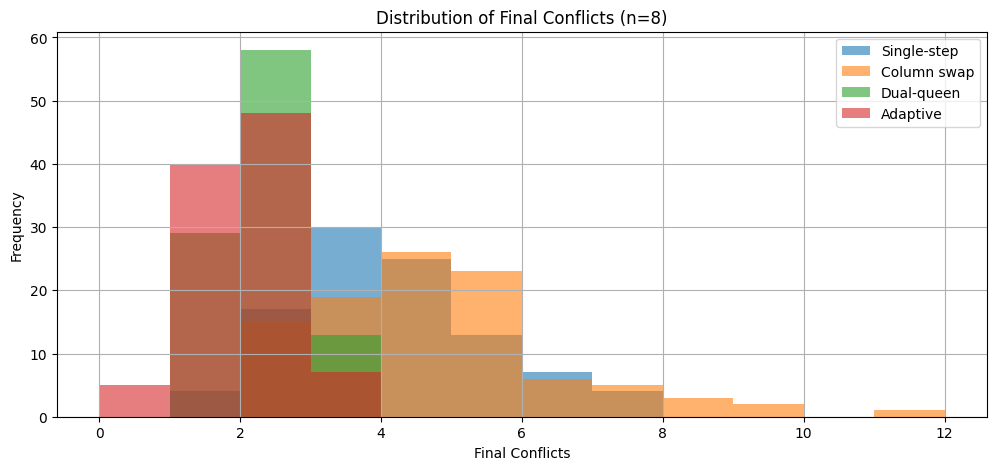


 Average Time to Solution (successful runs only) for n=8:
Single-step: No successful runs
Column swap: No successful runs
Dual-queen: No successful runs
Adaptive: 0.0016 seconds

=== Running experiments for n = 12 ===


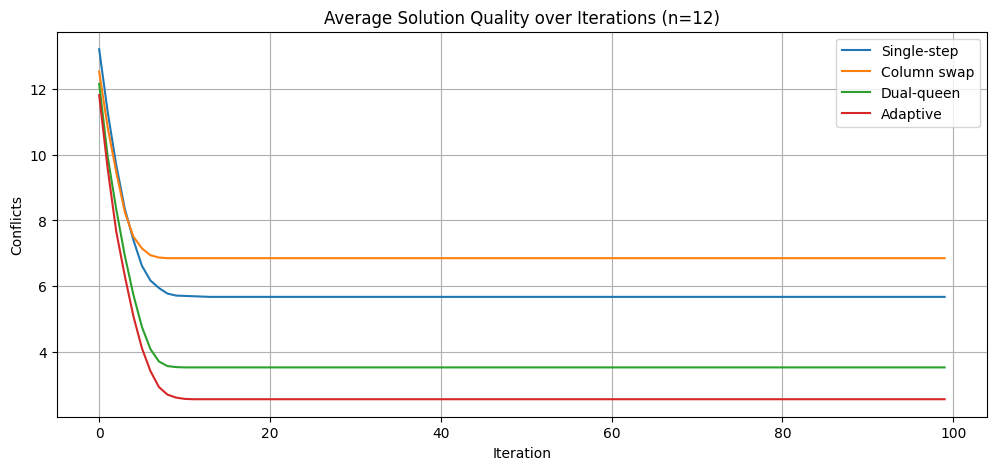

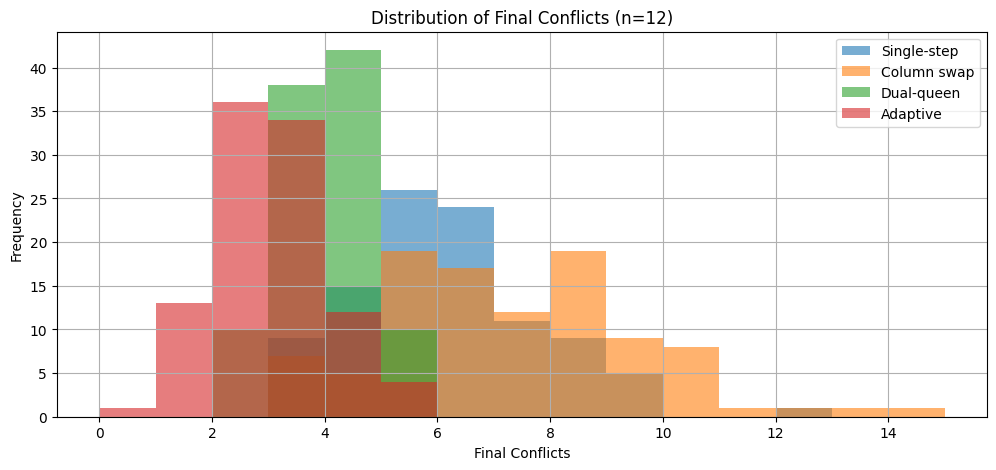


 Average Time to Solution (successful runs only) for n=12:
Single-step: No successful runs
Column swap: No successful runs
Dual-queen: No successful runs
Adaptive: 0.0109 seconds


In [40]:
operators = [
    ("Single-step", single_step_move),
    ("Column swap", column_swap),
    ("Dual-queen", dual_queen_move),
    ("Adaptive", adaptive_move)
]

for n in [8, 12]:
    print(f"\n=== Running experiments for n = {n} ===")
    results = [run_experiments(n, op, label) for label, op in operators]
    plot_results(results, n)


### 🔍 Discussion: Local Move Operators

| Move Operator   | Đặc điểm | Hiệu quả |
|----------------|----------|----------|
| **Single-step** | Di chuyển nhẹ, ít thay đổi | Chậm hội tụ, dễ bị kẹt |
| **Column swap** | Đổi vị trí 2 quân hậu | Giúp thoát local optima, nhưng không cải thiện xung đột trực tiếp |
| **Dual-queen**  | Di chuyển 2 quân cùng lúc | Tạo thay đổi lớn, hội tụ nhanh hơn |
| **Adaptive**    | Tùy trạng thái, chọn chiến lược phù hợp | Hiệu quả nhất, cân bằng giữa khai phá và khai thác |

**Kết luận:**  
Trong các thử nghiệm, **Adaptive move** cho kết quả tốt nhất cả về chất lượng lời giải và thời gian hội tụ.  
**Dual-queen move** cũng cho kết quả ổn định.  
**Single-step** thường bị kẹt ở local optima, còn **Column swap** giúp thoát nhưng không cải thiện trực tiếp xung đột.


## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Implement a Genetic Algorithm for the n-Queens problem

✅ Found solution at generation 170
Final board:
Board with 0 conflicts.


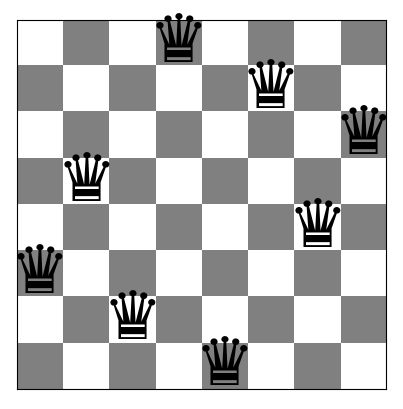

Queens (left to right) are at rows: [5, 3, 6, 0, 7, 1, 4, 2]
Number of conflicts: 0


In [41]:
# Code and description go here
import random

def genetic_algorithm(n, population_size=100, generations=500, mutation_rate=0.1):
    def generate_individual():
        return [random.randint(0, n - 1) for _ in range(n)]

    def fitness(individual):
        return -conflicts(individual)  # càng ít xung đột càng tốt

    def crossover(parent1, parent2):
        point = random.randint(1, n - 2)
        child = parent1[:point] + parent2[point:]
        return child

    def mutate(individual):
        if random.random() < mutation_rate:
            col = random.randint(0, n - 1)
            individual[col] = random.randint(0, n - 1)
        return individual

    # Khởi tạo quần thể ban đầu
    population = [generate_individual() for _ in range(population_size)]

    for gen in range(generations):
        population.sort(key=fitness, reverse=True)
        if conflicts(population[0]) == 0:
            print(f"✅ Found solution at generation {gen}")
            return population[0]

        next_gen = population[:10]  # giữ lại 10 cá thể tốt nhất
        while len(next_gen) < population_size:
            p1, p2 = random.choices(population[:50], k=2)
            child = crossover(p1, p2)
            child = mutate(child)
            next_gen.append(child)

        population = next_gen

    print("⚠️ No perfect solution found.")
    return population[0]

# Chạy thử với n = 8
n = 8
solution = genetic_algorithm(n)
print("Final board:")
show_board(solution)
print(f"Queens (left to right) are at rows: {solution}")
print(f"Number of conflicts: {conflicts(solution)}")


In [ ]:
# **Genetic Algorithm (GA)** là một thuật toán tối ưu hóa dựa trên tiến hóa tự nhiên. Trong bài toán n-Queens, mỗi cá thể trong quần thể là một bàn cờ, được biểu diễn bằng một danh sách các hàng mà quân hậu đang đứng (mỗi cột có đúng một quân hậu).

#### Các thành phần chính:
# - **Cá thể (individual)**: Một bàn cờ ngẫu nhiên gồm n quân hậu.
# - **Fitness function**: Số xung đột càng ít thì fitness càng cao (fitness = -conflicts).
# - **Crossover**: Ghép hai cá thể bằng cách trộn nửa đầu của một cá thể với nửa sau của cá thể khác.
# - **Mutation**: Thay đổi ngẫu nhiên vị trí của một quân hậu để tạo đa dạng.
# - **Selection**: Chọn các cá thể tốt nhất để tạo thế hệ tiếp theo.

#### Quy trình:
# 1. Khởi tạo quần thể ngẫu nhiên.
# 2. Đánh giá fitness của từng cá thể.
# 3. Chọn các cá thể tốt nhất để lai ghép và đột biến.
# 4. Lặp lại qua nhiều thế hệ cho đến khi tìm được lời giải hoặc hết số vòng lặp.

# **Ưu điểm**: Có khả năng thoát khỏi local optima nhờ crossover và mutation.  
# **Nhược điểm**: Cần điều chỉnh tham số tốt (population size, mutation rate, generations) để hội tụ nhanh.

